# music2emo — Mood Prediction Benchmark

Evaluates **music2emo** (MERT embeddings + chord/key features, multi-task learning)
on three annotated datasets and five qualitative spot-checks.

> **Run this notebook in its own Colab runtime** — do not mix with `01_essentia_benchmark.ipynb`.
> music2emo requires numpy ≥2.x; Essentia requires numpy ~1.x.

### Sections
0. Environment setup
1. Shared evaluation utilities
2. Predictor
3. Datasets
4. Evaluation
5. Qualitative spot-checks
6. Profiling
7. Summary & cross-model comparison

## 0. Environment Setup

In [1]:
# Install music2emo inference dependencies.
# Mirrors exp/emo2music/requirements.txt — no numpy version pin, so numpy 2.x
# (pre-installed on Colab/Kaggle) is preserved and pandas stays compatible.
# music2emo code + weights are fetched via snapshot_download in Section 2.
%pip install transformers soundfile librosa mir_eval pretty_midi music21 \
             hydra-core omegaconf pytorch_lightning \
             yt-dlp matplotlib pandas scipy tqdm gdown -q
print("Setup complete.")

Note: you may need to restart the kernel to use updated packages.
Setup complete.



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


## 1. Shared Evaluation Utilities

In [2]:
import sys
from pathlib import Path

# REPO_BRANCH: update to "main" after the PR is merged
REPO_BRANCH = "feat/mood-model-benchmark"
REPO_NAME   = "Soundtrack-Mood-Manager"

_cwd = Path.cwd()
if (_cwd / "eval_datasets.py").exists():
    _eval_dir = _cwd
else:
    _repo_root = _cwd / REPO_NAME
    if not (_repo_root / "evaluation").exists():
        !git clone --depth 1 --branch {REPO_BRANCH} \
            https://github.com/francescovidaich964/{REPO_NAME}.git
    _eval_dir = _repo_root / "evaluation"

_eval_dir = _eval_dir.resolve()
if str(_eval_dir) not in sys.path:
    sys.path.insert(0, str(_eval_dir))

from eval_datasets import setup_deam, setup_emomusic, setup_pmemo, setup_merge
from metrics import compute_metrics, print_metrics
from visualization import plot_scatter, cross_dataset_comparison
from spot_checks import SPOT_CHECKS, download_spot_checks, run_evaluation, profile_predictor

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_DIR      = Path("data")
SPOTCHECK_DIR = Path("spotchecks")
for d in [DATA_DIR, SPOTCHECK_DIR]:
    d.mkdir(exist_ok=True)

MODEL_TAG = "music2emo"
print(f"Imports complete. (eval_dir={_eval_dir})")

Imports complete. (eval_dir=C:\Projects\personal\Soundtrack-Mood-Manager\evaluation)


## 2. Predictor

Downloads ~500 MB of weights from Hugging Face (`amaai-lab/music2emo`) on first instantiation.

In [3]:
import functools, os, sys
from pathlib import Path
import numpy as np
import soundfile as sf
import torch
import torchaudio
from huggingface_hub import snapshot_download

# ── Download music2emo code + weights from HuggingFace ───────────────────────
print("Fetching music2emo from HuggingFace (cached after first run)...")
_M2E_ROOT = Path(snapshot_download("amaai-lab/music2emo"))
if str(_M2E_ROOT) not in sys.path:
    sys.path.insert(0, str(_M2E_ROOT))
print(f"music2emo root: {_M2E_ROOT}")

# Suppress per-inference INFO messages from absl-py
# ("audio file loaded and feature computation success : ...")
# WARNING and above are still shown so real errors are not hidden.
try:
    from absl import logging as _absl_logging
    _absl_logging.set_verbosity(_absl_logging.WARNING)
except ImportError:
    pass

# ── Patches (same as exp/emo2music/src/feature_extractor.py) ─────────────────

if "gradio" not in sys.modules:
    from unittest.mock import MagicMock as _MagicMock
    sys.modules["gradio"] = _MagicMock()

def _sf_load(uri, frame_offset=0, num_frames=-1, normalize=True,
             channels_first=True, format=None, buffer_size=4096, backend=None):
    start = frame_offset
    stop = None if num_frames < 0 else frame_offset + num_frames
    data, sr = sf.read(str(uri), dtype="float32", always_2d=True, start=start, stop=stop)
    arr = data.T if channels_first else data
    return torch.from_numpy(np.ascontiguousarray(arr)), sr

torchaudio.load = _sf_load

_orig_torch_load = torch.load
@functools.wraps(_orig_torch_load)
def _cpu_torch_load(f, map_location=None, weights_only=False, **kwargs):
    return _orig_torch_load(f, map_location=map_location or "cpu",
                            weights_only=weights_only, **kwargs)
torch.load = _cpu_torch_load

# ── Predictor ──────────────────────────────────────────────────────────────────

class Music2EmoPredictor:
    """music2emo: MERT embeddings + chord/key features, multi-task learning.

    Mirrors src/feature_extractor.py on branch exp/emo2music:
    - Uses snapshot_download (not git clone) — same source as production.
    - os.chdir(_M2E_ROOT) wraps both __init__ and predict() because music2emo
      uses hardcoded relative paths (./inference/data/, ./saved_models/, etc.).
    - Audio path is resolved to absolute BEFORE chdir so it survives the change.
    """

    def __init__(self):
        print("Loading music2emo...")
        old_cwd = os.getcwd()
        os.chdir(_M2E_ROOT)
        try:
            from music2emo import Music2emo
            self._model = Music2emo()
        finally:
            os.chdir(old_cwd)
        print("Music2EmoPredictor ready.")

    def predict(self, audio_path) -> dict | None:
        """Returns {'valence': float, 'arousal': float} in [0, 1], or None on failure."""
        audio_abs = str(Path(audio_path).resolve())
        old_cwd = os.getcwd()
        os.chdir(_M2E_ROOT)
        try:
            out = self._model.predict(audio_abs, threshold=0.5)
        except Exception:
            return None
        finally:
            os.chdir(old_cwd)
        valence = float(np.clip((out["valence"] - 1.0) / 8.0, 0.0, 1.0))
        arousal = float(np.clip((out["arousal"] - 1.0) / 8.0, 0.0, 1.0))
        return {"valence": valence, "arousal": arousal,
                "moods": out.get("predicted_moods", [])}


predictor = Music2EmoPredictor()

device = predictor._model.device
print(f"\nmusic2emo running on: {device}")
if str(device) == "cpu":
    print("  ⚠  Running on CPU. For GPU: Runtime → Change runtime type → T4 GPU, then restart.")
else:
    print(f"  ✓ GPU detected: {torch.cuda.get_device_name(0)}")

Fetching music2emo from HuggingFace (cached after first run)...


Fetching 90 files:   0%|          | 0/90 [00:00<?, ?it/s]

music2emo root: C:\Users\FrancescoVidaich\.cache\huggingface\hub\models--amaai-lab--music2emo\snapshots\b036e59471583c3d5b30c69e63e8c7323cc36c4a
Loading music2emo...


W0608 14:25:36.834000 39528 Lib\site-packages\torch\utils\flop_counter.py:29] triton not found; flop counting will not work for triton kernels
[transformers] The following layers were not sharded: masked_spec_embed, encoder.layers.*.attention.q_proj.weight, encoder.layers.*.feed_forward.output_dense.weight, feature_projection.projection.weight, encoder.layers.*.attention.v_proj.weight, encoder.layers.*.layer_norm.bias, encoder.layers.*.attention.v_proj.bias, encoder.layers.*.feed_forward.intermediate_dense.bias, encoder.layer_norm.bias, encoder.layers.*.attention.k_proj.bias, encoder.layers.*.feed_forward.intermediate_dense.weight, feature_projection.layer_norm.weight, encoder.pos_conv_embed.conv.parametrizations.weight.original1, encoder.layer_norm.weight, encoder.layers.*.layer_norm.weight, feature_extractor.conv_layers.*.conv.weight, feature_extractor.conv_layers.*.layer_norm.bias, encoder.layers.*.feed_forward.output_dense.bias, encoder.layers.*.final_layer_norm.bias, encoder.layer

Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

Music2EmoPredictor ready.

music2emo running on: cuda
  ✓ GPU detected: NVIDIA RTX 2000 Ada Generation Laptop GPU


## 3. Datasets

Same dataset helpers as the Essentia notebook.

In [4]:
df_deam,     deam_id, deam_val, deam_aro = setup_deam(DATA_DIR,  download_audio=True)
df_emomusic, em_id,   em_val,   em_aro   = setup_emomusic(DATA_DIR)
df_pmemo,    pm_id,   pm_val,   pm_aro   = setup_pmemo(DATA_DIR)
df_merge,    mg_id,   mg_val,   mg_aro   = setup_merge(DATA_DIR, download_audio=True)

  ✓ DEAM_audio.zip (cached)
  ✓ DEAM_Annotations.zip (cached)
Extracting DEAM_Annotations.zip...
Extracting DEAM_audio.zip...
DEAM: 1802 songs  id='song_id'  valence='valence_mean'  arousal='arousal_mean'
⚠  EmoMusic unavailable — official download links return 404 (as of 2025-06).
   If you have a local copy, place annotations.csv in data/emomusic/
   and audio .mp3 files in data/emomusic/clips/


Retrieving folder contents


Processing file 1UzC3NCDj30j9Ba7i5lkMzWO5gFqSr0OJ PMEmo2019.zip
Processing file 1KQ0zjRiBQynnHyVPU7DGpUWvtPmCBOcq README.txt


Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From (original): https://drive.google.com/uc?id=1UzC3NCDj30j9Ba7i5lkMzWO5gFqSr0OJ
From (redirected): https://drive.google.com/uc?id=1UzC3NCDj30j9Ba7i5lkMzWO5gFqSr0OJ&confirm=t&uuid=1a40bfce-8dbd-4180-b975-25db43ebbc2d
To: c:\Projects\personal\Soundtrack-Mood-Manager\evaluation\data\pmemo\PMEmo2019.zip
100%|██████████| 680M/680M [00:58<00:00, 11.6MB/s] 
Downloading...
From: https://drive.google.com/uc?id=1KQ0zjRiBQynnHyVPU7DGpUWvtPmCBOcq
To: c:\Projects\personal\Soundtrack-Mood-Manager\evaluation\data\pmemo\README.txt
100%|██████████| 1.52k/1.52k [00:00<00:00, 5.57MB/s]
Download completed


Extracting PMEmo2019.zip...
PMEmo: 767 rows  id='musicId'  valence='Valence(mean)'  arousal='Arousal(mean)'
Extracting MERGE_Audio_Balanced.zip...
MERGE: 3232 rows  id='Song'  valence='Valence'  arousal='Arousal'


## 4. Evaluation

Adjust audio paths if your files are elsewhere (e.g. mounted Google Drive).

In [5]:
_deam_audio   = next(iter(sorted((DATA_DIR / "deam").rglob("MEMD_audio"))), None)
DEAM_AUDIO    = _deam_audio if _deam_audio else DATA_DIR / "deam" / "MEMD_audio"
if _deam_audio:
    print(f"DEAM audio  : {DEAM_AUDIO}")

EMOMUSIC_AUDIO = DATA_DIR / "emomusic" / "clips"

_pmemo_chorus = next(iter(sorted((DATA_DIR / "pmemo").rglob("chorus"))), None)
PMEMO_AUDIO   = _pmemo_chorus if _pmemo_chorus else DATA_DIR / "pmemo" / "chorus"
if _pmemo_chorus:
    print(f"PMEmo audio : {PMEMO_AUDIO}")

_merge_root   = next(iter(sorted((DATA_DIR / "merge").rglob("MERGE_Audio_Balanced"))), None)
MERGE_AUDIO   = _merge_root if _merge_root else DATA_DIR / "merge" / "MERGE_Audio_Balanced"
if _merge_root:
    print(f"MERGE audio : {MERGE_AUDIO}")

# TIP: Enable T4 GPU (Runtime → Change runtime type → T4 GPU).
#      music2emo (PyTorch) uses CUDA automatically when a GPU is present.
MAX_TRACKS = None

DATASETS = [
    ("DEAM",     df_deam,     DEAM_AUDIO,     deam_id, deam_val, deam_aro),
    ("EmoMusic", df_emomusic, EMOMUSIC_AUDIO, em_id,   em_val,   em_aro),
    ("PMEmo",    df_pmemo,    PMEMO_AUDIO,    pm_id,   pm_val,   pm_aro),
    ("MERGE",    df_merge,    MERGE_AUDIO,    mg_id,   mg_val,   mg_aro),
]

all_results = {}
for ds_name, df_a, audio_dir, id_col, val_col, aro_col in DATASETS:
    if df_a is None or not audio_dir.exists():
        print(f"Skipping {ds_name} — audio not found at {audio_dir}")
        continue
    all_results[ds_name] = run_evaluation(
        ds_name, MODEL_TAG, predictor.predict,
        audio_dir, df_a, id_col, val_col, aro_col, MAX_TRACKS,
    )

DEAM audio  : data\deam\MEMD_audio
PMEmo audio : data\pmemo\__MACOSX\PMEmo2019\chorus
MERGE audio : data\merge\MERGE_Audio_Balanced


DEAM / music2emo:   0%|          | 0/1802 [00:00<?, ?it/s]

[transformers] `use_return_dict` is deprecated! Use `return_dict` instead!
I C:\Users\FrancescoVidaich\.cache\huggingface\hub\models--amaai-lab--music2emo\snapshots\b036e59471583c3d5b30c69e63e8c7323cc36c4a 06-08 14:27:42.175 music2emo.py:286] audio file loaded and feature computation success : C:\Projects\personal\Soundtrack-Mood-Manager\evaluation\data\deam\MEMD_audio\10.mp3
I C:\Users\FrancescoVidaich\.cache\huggingface\hub\models--amaai-lab--music2emo\snapshots\b036e59471583c3d5b30c69e63e8c7323cc36c4a 06-08 14:27:43.799 music2emo.py:286] audio file loaded and feature computation success : C:\Projects\personal\Soundtrack-Mood-Manager\evaluation\data\deam\MEMD_audio\1000.mp3
I C:\Users\FrancescoVidaich\.cache\huggingface\hub\models--amaai-lab--music2emo\snapshots\b036e59471583c3d5b30c69e63e8c7323cc36c4a 06-08 14:27:45.483 music2emo.py:286] audio file loaded and feature computation success : C:\Projects\personal\Soundtrack-Mood-Manager\evaluation\data\deam\MEMD_audio\1001.mp3
I C:\User

DEAM: 1802 tracks  |  OK: 1756  |  failed: 46
Skipping EmoMusic — audio not found at data\emomusic\clips


PMEmo / music2emo:   0%|          | 0/2 [00:00<?, ?it/s]

MERGE / music2emo:   0%|          | 0/3232 [00:00<?, ?it/s]

I C:\Users\FrancescoVidaich\.cache\huggingface\hub\models--amaai-lab--music2emo\snapshots\b036e59471583c3d5b30c69e63e8c7323cc36c4a 06-08 15:14:48.281 music2emo.py:286] audio file loaded and feature computation success : C:\Projects\personal\Soundtrack-Mood-Manager\evaluation\data\merge\MERGE_Audio_Balanced\Q1\A005.mp3
I C:\Users\FrancescoVidaich\.cache\huggingface\hub\models--amaai-lab--music2emo\snapshots\b036e59471583c3d5b30c69e63e8c7323cc36c4a 06-08 15:14:49.751 music2emo.py:286] audio file loaded and feature computation success : C:\Projects\personal\Soundtrack-Mood-Manager\evaluation\data\merge\MERGE_Audio_Balanced\Q1\A011.mp3
I C:\Users\FrancescoVidaich\.cache\huggingface\hub\models--amaai-lab--music2emo\snapshots\b036e59471583c3d5b30c69e63e8c7323cc36c4a 06-08 15:14:50.738 music2emo.py:286] audio file loaded and feature computation success : C:\Projects\personal\Soundtrack-Mood-Manager\evaluation\data\merge\MERGE_Audio_Balanced\Q1\A014.mp3
I C:\Users\FrancescoVidaich\.cache\huggi

MERGE: 3232 tracks  |  OK: 3082  |  failed: 150



── DEAM ──
  DEAM:
        Dim    n    MAE     R² Pearson r Kendall τ
    valence 1756 0.1009 0.2497    0.6550    0.4777
    arousal 1756 0.0919 0.4603    0.7586    0.5727


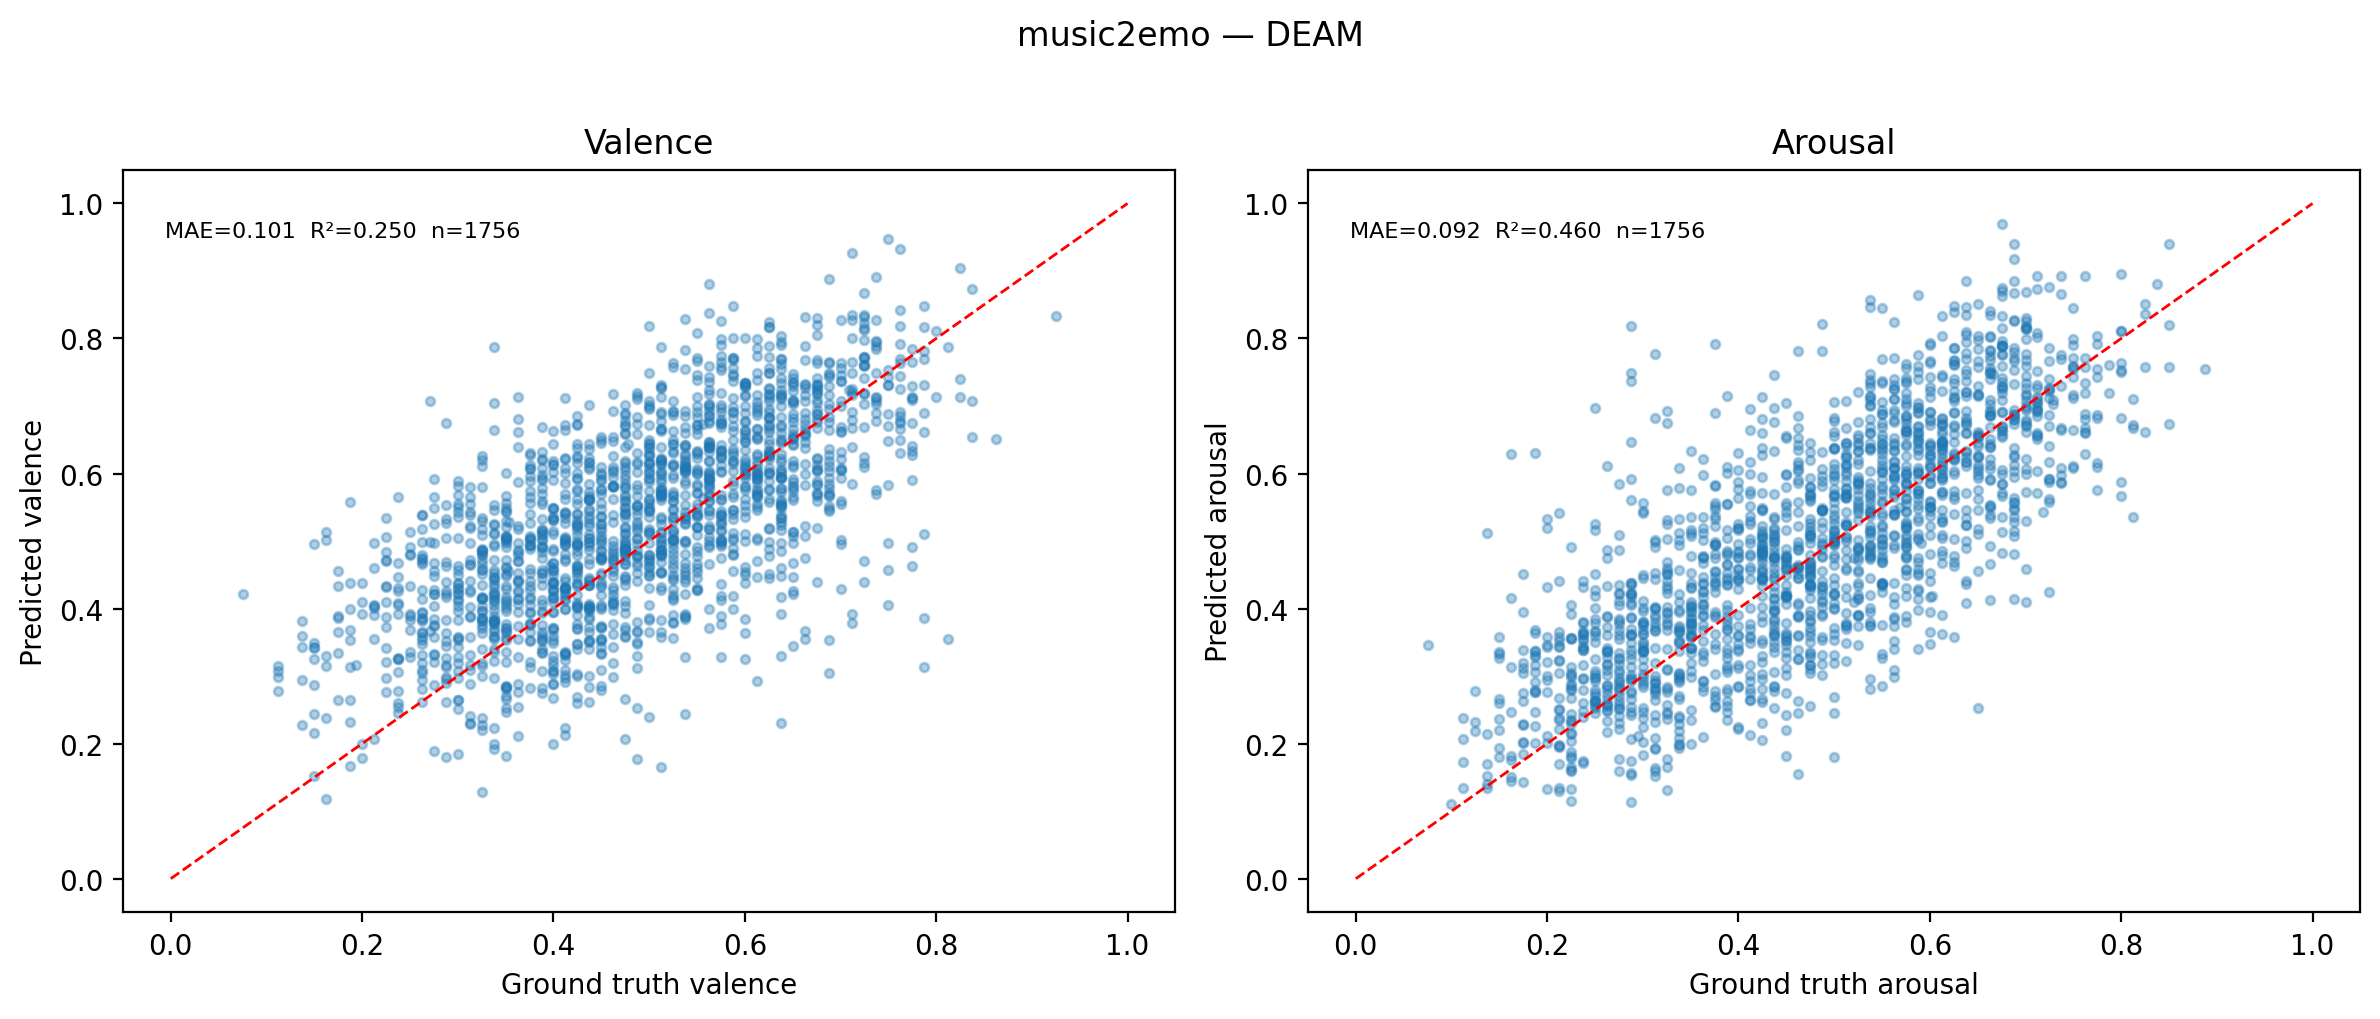

Saved: music2emo_—_deam.png
No results for PMEmo.
No data to plot for music2emo — PMEmo.

── MERGE ──
  MERGE:
        Dim    n    MAE      R² Pearson r Kendall τ
    valence 3082 0.1889  0.0202    0.3159    0.2283
    arousal 3082 0.1156 -0.1236    0.6672    0.4655


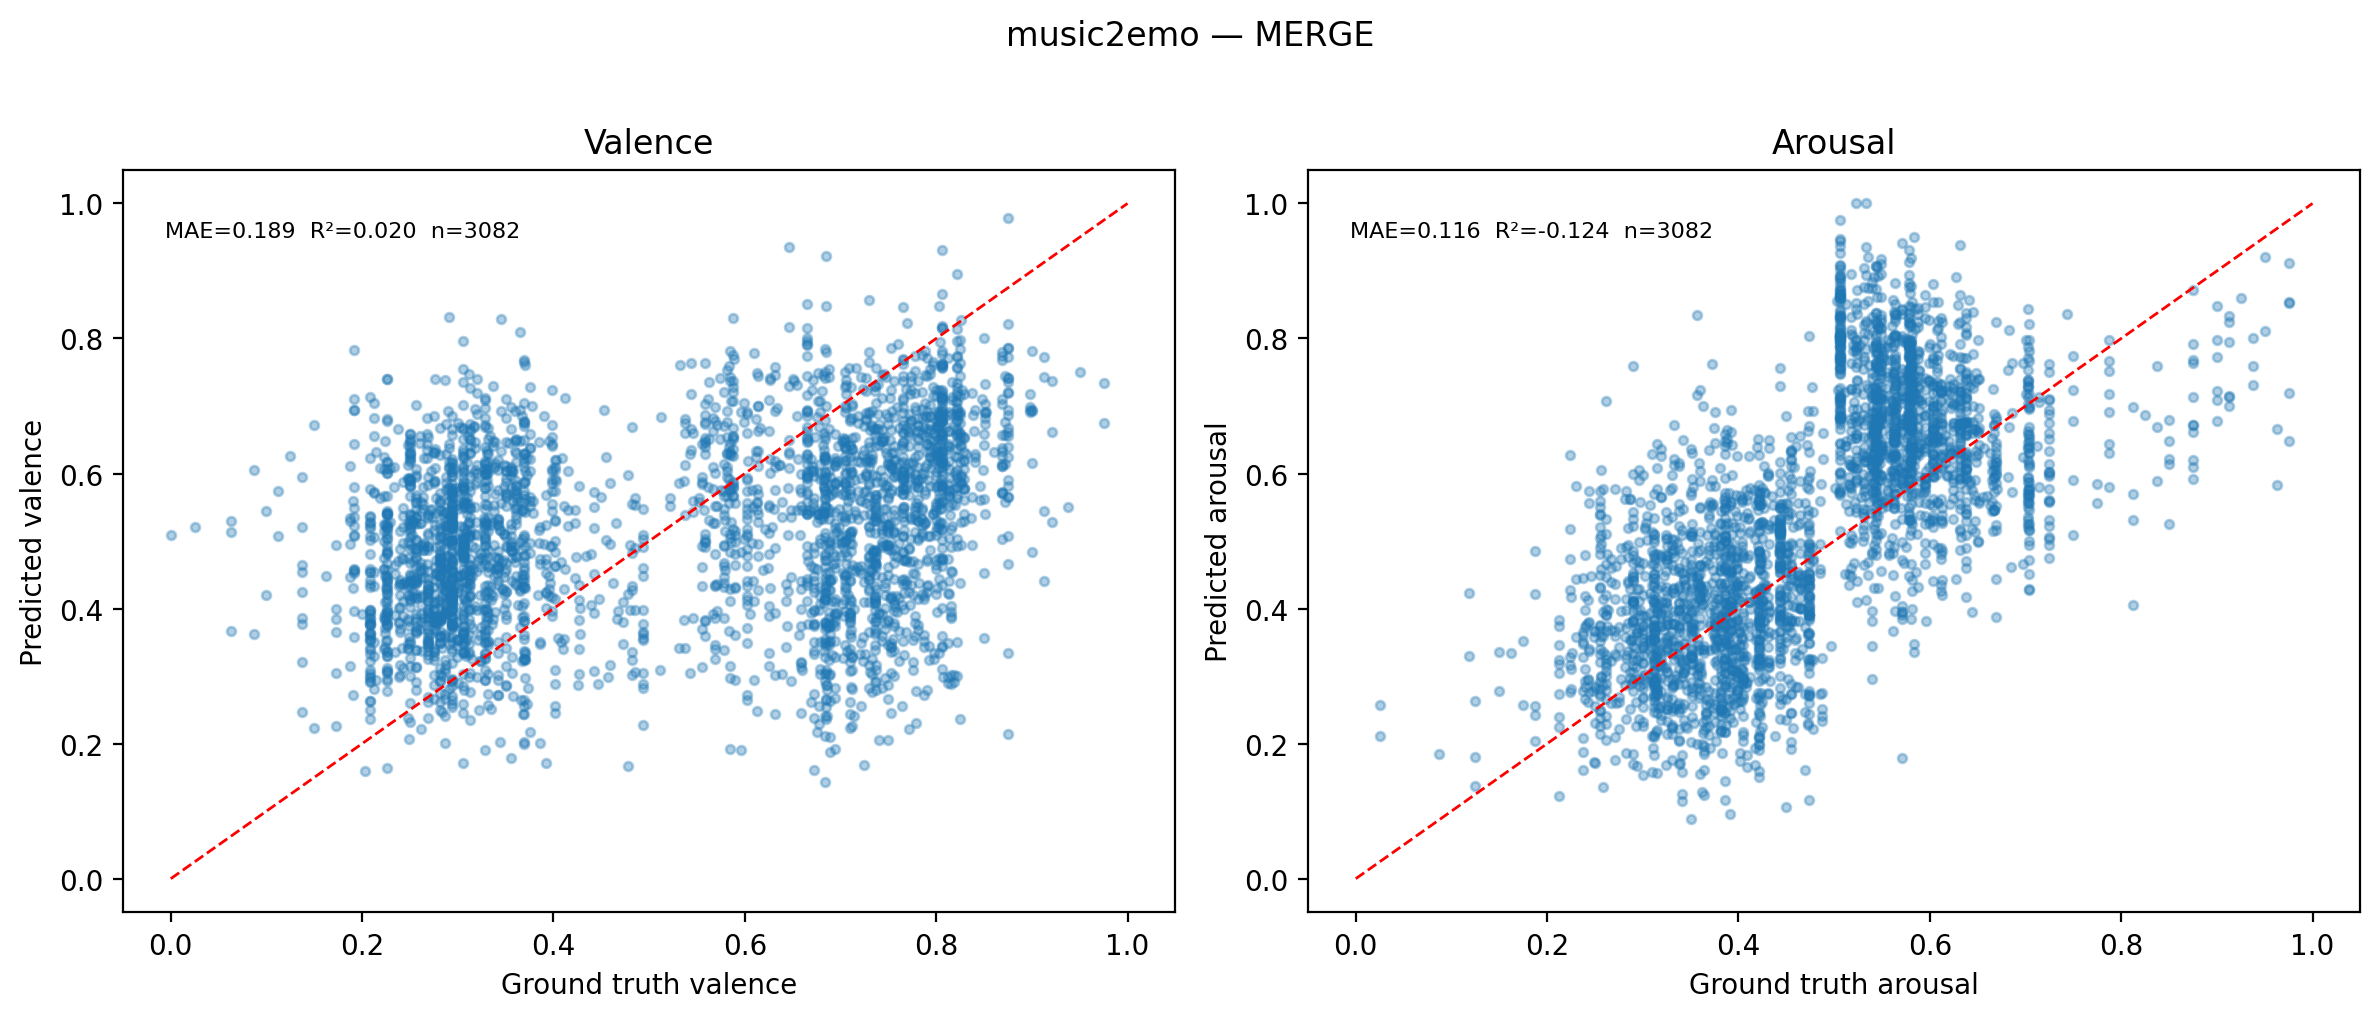

Saved: music2emo_—_merge.png


In [6]:
for ds_name, df in all_results.items():
    print_metrics(df, ds_name)
    plot_scatter(df, f"music2emo — {ds_name}")

In [7]:
if all_results:
    combined = pd.concat(all_results.values())
    out = f"{MODEL_TAG}_results.csv"
    combined.to_csv(out, index=False)
    print(f"Saved: {out}  ({len(combined)} rows)")
else:
    print("No results to save — check that audio directories exist.")

Saved: music2emo_results.csv  (5034 rows)


## 5. Qualitative Spot-checks

In [15]:
download_spot_checks(SPOTCHECK_DIR)

  stderr: 
  stderr: 
  stderr: 
  stderr: 
  stderr: 


In [9]:
spot_rows = []
for track in SPOT_CHECKS:
    audio = SPOTCHECK_DIR / f"{track['title']}.mp3"
    if not audio.exists():
        print(f"  ✗ {track['title']} — not found, skipping")
        continue
    pred = predictor.predict(audio)
    spot_rows.append({
        "title":       track["title"].replace("_", " "),
        "exp_valence": track["exp_valence"],
        "exp_arousal": track["exp_arousal"],
        "valence":     pred["valence"] if pred else float("nan"),
        "arousal":     pred["arousal"] if pred else float("nan"),
        "moods":       ", ".join((pred.get("moods") or [])[:4]) if pred else "",
    })
    name = track["title"].replace("_", " ").title()
    print(f"\n{name}")
    print(f"  Expected:  v={track['exp_valence']:.2f}  a={track['exp_arousal']:.2f}")
    if pred:
        moods = ", ".join((pred.get("moods") or [])[:4])
        print(f"  Predicted: v={pred['valence']:.2f}  a={pred['arousal']:.2f}  moods=[{moods}]")
    else:
        print("  Predicted: FAILED")

spot_df = pd.DataFrame(spot_rows)
print(f"\nCompleted {len(spot_df)} spot-checks.")

  ✗ dont_stop_me_now — not found, skipping
  ✗ clair_de_lune — not found, skipping
  ✗ killing_in_the_name — not found, skipping
  ✗ hurt_johnny_cash — not found, skipping
  ✗ walking_on_sunshine — not found, skipping

Completed 0 spot-checks.


In [10]:
if not spot_df.empty:
    colors = plt.cm.tab10(np.linspace(0, 0.9, len(spot_df)))
    fig, ax = plt.subplots(figsize=(7, 7))
    ax.set_xlim(-0.05, 1.05); ax.set_ylim(-0.05, 1.05)
    ax.axhline(0.5, color="#ccc", lw=0.8, ls="--"); ax.axvline(0.5, color="#ccc", lw=0.8, ls="--")
    ax.text(0.02, 0.98, "sad/energetic",   transform=ax.transAxes, va="top",    fontsize=8, color="#999")
    ax.text(0.98, 0.98, "happy/energetic",  transform=ax.transAxes, va="top",    ha="right", fontsize=8, color="#999")
    ax.text(0.02, 0.02, "sad/calm",         transform=ax.transAxes, va="bottom", fontsize=8, color="#999")
    ax.text(0.98, 0.02, "happy/calm",       transform=ax.transAxes, va="bottom", ha="right", fontsize=8, color="#999")
    for i, row in spot_df.iterrows():
        c = colors[i]
        ax.scatter(row["exp_valence"], row["exp_arousal"], marker="*", s=220, color=c, zorder=4)
        if not pd.isna(row["valence"]):
            ax.scatter(row["valence"], row["arousal"], marker="o", s=70,
                       color=c, edgecolors="black", lw=0.5, zorder=4)
            ax.annotate("", xy=(row["valence"], row["arousal"]),
                        xytext=(row["exp_valence"], row["exp_arousal"]),
                        arrowprops=dict(arrowstyle="->", color=c, lw=1.0))
        ax.annotate(row["title"], xy=(row["exp_valence"], row["exp_arousal"]),
                    xytext=(5, 5), textcoords="offset points", fontsize=7, color=c)
    ax.set_xlabel("Valence (sad → happy)")
    ax.set_ylabel("Arousal (calm → energetic)")
    ax.set_title("music2emo — Spot-checks\n★ = expected  ● = predicted")
    plt.tight_layout()
    plt.savefig(f"{MODEL_TAG}_spotchecks.png", dpi=120, bbox_inches="tight")
    plt.show()

## 6. Runtime & Memory Profiling

In [11]:
test_audio = next(
    (SPOTCHECK_DIR / f"{t['title']}.mp3" for t in SPOT_CHECKS
     if (SPOTCHECK_DIR / f"{t['title']}.mp3").exists()),
    None,
)

if test_audio is None:
    print("No audio for profiling — run Section 5 first.")
else:
    prof = profile_predictor(predictor.predict, test_audio, n=5)
    print(f"music2emo — profiling on {test_audio.name}:")
    print(f"  Mean: {prof['mean_s']:.2f} s/track")
    print(f"  Std:  {prof['std_s']:.3f} s")
    print(f"  Peak RAM: {prof['peak_mb']:.1f} MB  (Python heap; GPU memory not included)")

No audio for profiling — run Section 5 first.


## 7. Summary & Cross-Model Comparison

The cross-model comparison requires `essentia_results.csv` from notebook 1.
Place it in the same working directory, or update the path below.

In [12]:
print("=" * 60)
print("MUSIC2EMO — BENCHMARK SUMMARY")
print("=" * 60)

print("\n── Dataset metrics ──")
if all_results:
    combined_m2e = pd.concat(all_results.values())
    print_metrics(combined_m2e, "all datasets")
else:
    print("  (no datasets evaluated)")

print("\n── Spot-checks ──")
if not spot_df.empty:
    print(spot_df[["title", "exp_valence", "exp_arousal", "valence", "arousal", "moods"]]
          .to_string(index=False, float_format="{:.2f}".format))
else:
    print("  (none run)")

print("\n── Runtime ──")
if "prof" in dir():
    print(f"  {prof['mean_s']:.2f} s/track  (peak RAM {prof['peak_mb']:.1f} MB)")
else:
    print("  (run Section 6 to profile)")

print("\n" + "=" * 60)

MUSIC2EMO — BENCHMARK SUMMARY

── Dataset metrics ──

── all datasets ──
  DEAM:
        Dim    n    MAE     R² Pearson r Kendall τ
    valence 1756 0.1009 0.2497    0.6550    0.4777
    arousal 1756 0.0919 0.4603    0.7586    0.5727
  MERGE:
        Dim    n    MAE      R² Pearson r Kendall τ
    valence 3082 0.1889  0.0202    0.3159    0.2283
    arousal 3082 0.1156 -0.1236    0.6672    0.4655

── Spot-checks ──
  (none run)

── Runtime ──
  (run Section 6 to profile)



In [13]:
# ── Cross-model comparison (requires essentia_results.csv from notebook 1) ───
essentia_csv = Path("essentia_results.csv")

if not essentia_csv.exists():
    print(f"⚠  {essentia_csv} not found.")
    print("   Run 01_essentia_benchmark.ipynb first and copy the CSV here.")
elif not all_results:
    print("No music2emo results to compare — run Section 4 first.")
else:
    df_essentia = pd.read_csv(essentia_csv)
    combined_all = pd.concat([df_essentia, pd.concat(all_results.values())])
    cross_dataset_comparison(combined_all)

⚠  essentia_results.csv not found.
   Run 01_essentia_benchmark.ipynb first and copy the CSV here.
